In [1]:
import polars as pl
import numpy as np

MIN_PER_WEEK = 7 * 24 * 60          # 10080
N_WEEKS = 8

# ---- One pass over raw data: distinct (user, minute) points ----
base = (
    pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                             'auth_type','logon_type','auth_orientation','outcome'])
    .filter(pl.col('src_user').str.starts_with('U'))
    .filter(pl.col('time') < N_WEEKS * MIN_PER_WEEK * 60)
    .select(
        'src_user',
        (pl.col('time') // 60).alias('minute'),   # integer minutes since start
    )
    .unique()
    .collect(engine='streaming')
)

# ---- Per-level Jaccard, all derived from `base` in memory ----
def jaccard_by_week(agg_minutes: int) -> np.ndarray:
    pts = (
        base.select(
            'src_user',
            (pl.col('minute') // MIN_PER_WEEK).alias('week'),
            ((pl.col('minute') % MIN_PER_WEEK) // agg_minutes).alias('rel_bucket'),
        )
        .unique()
    )

    sizes = dict(pts.group_by('week').len().iter_rows())

    # a row of week w survives the semi-join iff the same (user, rel_bucket)
    # also exists in week w+1
    shifted = pts.with_columns(pl.col('week') - 1)
    inter = dict(
        pts.join(shifted, on=['src_user', 'week', 'rel_bucket'], how='semi')
           .group_by('week').len().iter_rows()
    )

    return np.array([
        inter.get(w, 0) / (sizes[w] + sizes[w + 1] - inter.get(w, 0))
        for w in range(N_WEEKS - 1)
    ])

levels = {'1 min': 1, '10 min': 10, '30 min': 30, '1 h': 60, '2 h': 120,
          '3 h': 180, '4 h': 240, '6 h': 360, '8 h': 480, '12 h': 720,
          '24 h': 1440, '1 week': MIN_PER_WEEK}   # 1 week = the persistence limit

results = {name: jaccard_by_week(m) for name, m in levels.items()}

for name, js in results.items():
    print(f"{name:>7}:  mean {js.mean():.3f}   sd {js.std(ddof=1):.3f}")

  1 min:  mean 0.160   sd 0.013
 10 min:  mean 0.304   sd 0.014
 30 min:  mean 0.469   sd 0.021
    1 h:  mean 0.596   sd 0.030
    2 h:  mean 0.639   sd 0.039
    3 h:  mean 0.631   sd 0.038
    4 h:  mean 0.625   sd 0.036
    6 h:  mean 0.617   sd 0.035
    8 h:  mean 0.613   sd 0.034
   12 h:  mean 0.596   sd 0.032
   24 h:  mean 0.589   sd 0.028
 1 week:  mean 0.711   sd 0.020


In [3]:
import matplotlib.pyplot as plt

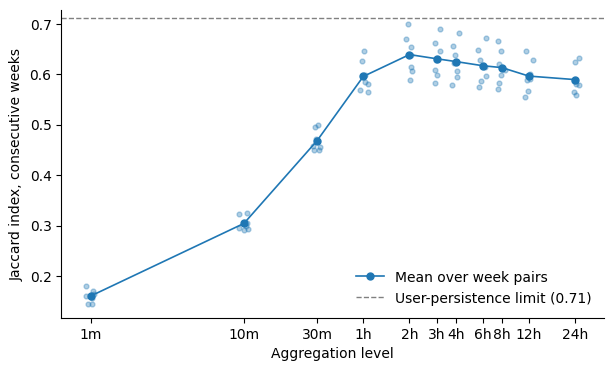

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
rng = np.random.default_rng(0)

curve = {k: v for k, v in results.items() if k != '1 week'}
mins = np.array([1, 10, 30, 60, 120, 180, 240, 360, 480, 720, 1440])

for x, js in zip(mins, curve.values()):
    jitter = x * rng.uniform(0.93, 1.07, size=len(js))   # multiplicative: log axis
    ax.scatter(jitter, js, s=12, color='tab:blue', alpha=0.35, zorder=2)

means = np.array([js.mean() for js in curve.values()])
ax.plot(mins, means, marker='o', ms=5, lw=1.2, color='tab:blue',
        zorder=3, label='Mean over week pairs')

ax.axhline(results['1 week'].mean(), ls='--', lw=1, color='grey',
           label=f"User-persistence limit ({results['1 week'].mean():.2f})")

ax.set_xscale('log')
ax.set_xticks(mins)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Jaccard index, consecutive weeks')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)